# Banking Fraud Detection — SMOTE Experiment

This notebook investigates whether SMOTE can improve fraud detection by balancing the training data while keeping the temporal test data unchanged.

In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [11]:
train_df = pd.read_csv("../data/train_temporal.csv")
test_df = pd.read_csv("../data/test_temporal.csv")

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Training data: (8000, 10)
Testing data: (2000, 10)


In [12]:
target = "is_fraud"

train_df["timestamp"] = pd.to_datetime(train_df["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

for d in [train_df, test_df]:
    d["hour_of_day"] = d["timestamp"].dt.hour
    d["day_of_week"] = d["timestamp"].dt.dayofweek

drop_columns = [
    "is_fraud",
    "transaction_id",
    "customer_id",
    "timestamp"
]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

In [13]:
categorical_features = [
    "merchant_category",
    "customer_location",
    "device_type"
]

numerical_features = [
    "amount",
    "customer_age",
    "previous_transactions",
    "hour_of_day",
    "day_of_week"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

X_train_final = np.hstack([
    X_train_num,
    X_train_cat
])

X_test_final = np.hstack([
    X_test_num,
    X_test_cat
])

In [14]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_final,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    7856
1     144
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7856
1    7856
Name: count, dtype: int64


In [15]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss"
    )
}

In [16]:
results = []

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "PR-AUC": average_precision_score(
            y_test, y_prob
        )
    })

    probs_fraud = y_prob[y_test == 1]
    probs_legit = y_prob[y_test == 0]
    print(f"{name}: mean prob (fraud) = {probs_fraud.mean():.4f}, mean prob (legit) = {probs_legit.mean():.4f}")

smote_results_df = pd.DataFrame(results)
smote_results_df.to_csv("../results/smote_results.csv", index=False)

smote_results_df

Logistic Regression: mean prob (fraud) = 0.4699, mean prob (legit) = 0.4792
Random Forest: mean prob (fraud) = 0.0339, mean prob (legit) = 0.0345
XGBoost: mean prob (fraud) = 0.0049, mean prob (legit) = 0.0140


,Model,Precision,Recall,F1-Score,PR-AUC
0,Logistic Regression,0.021396,0.431818,0.040773,0.021442
1,Random Forest,0.000000,0.000000,0.000000,0.023403
2,XGBoost,0.000000,0.000000,0.000000,0.019181


In [17]:
feature_names = numerical_features + list(encoder.get_feature_names_out(categorical_features))
importances = pd.Series(
    models["Random Forest"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)
print(importances.head(10))

previous_transactions              0.116697
day_of_week                        0.093317
customer_age                       0.068412
hour_of_day                        0.068371
customer_location_FL               0.067653
amount                             0.067023
merchant_category_fashion          0.057808
customer_location_IL               0.052243
merchant_category_entertainment    0.050319
customer_location_TX               0.049500
dtype: float64


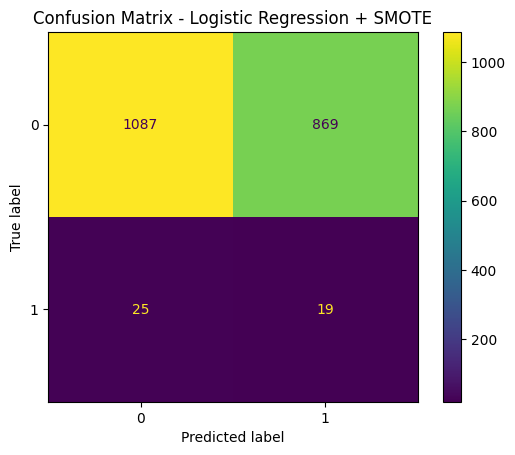

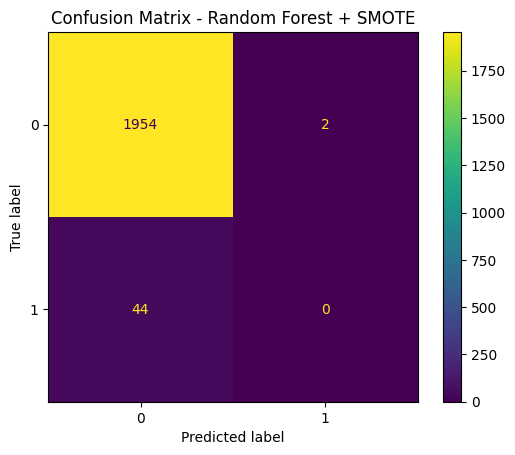

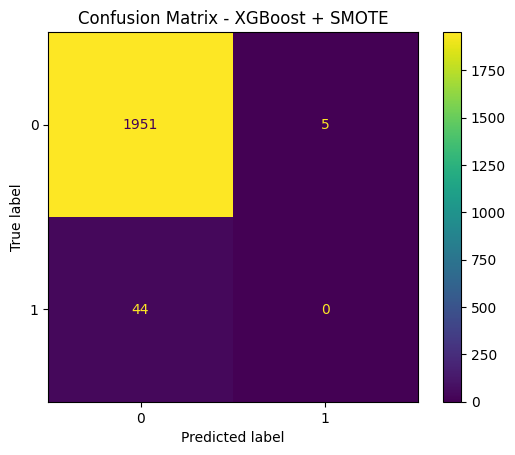

In [18]:
for name, model in models.items():

    y_pred = model.predict(X_test_final)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title(f"Confusion Matrix - {name} + SMOTE")
    plt.show()

### Observations

- SMOTE balanced the training data by increasing the minority class from 144 to 7,856 samples.
- Logistic Regression showed a significant improvement in recall, increasing from 0.00 in the baseline experiment to 0.50 after SMOTE.
- However, this improvement came with a large increase in false positives, resulting in a low precision of 0.0249.
- Random Forest and XGBoost still achieved zero recall at the default classification threshold.
- XGBoost achieved the highest PR-AUC (0.02653) among the SMOTE models, indicating the best probability-ranking performance among the three models.
- Overall, SMOTE improved fraud detection for Logistic Regression but did not provide a consistent improvement across all models.